# Sales Data Analysis with Python

### (A part of Big Data Analysis)

-------------

## Restaurant Sales Dataset
***
Here, 

We have the sales data of a restaurant company from different cities (countries).

This data is available in Excel file format. We are going to analyze and visualize this data.

-------------

In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [64]:
df = pd.read_excel('Sales-Data-Analysis.xlsx',header=1)

In [65]:
df

,Unnamed: 0,Order ID,Date,Product,Price,Quantity,Purchase Type,Payment Method,Manager,City
0,NaN,10452,2022-11-07,Fries,3.49,573.065903,Online,Gift Card,Tom Jackson,London
1,NaN,10453,2022-11-07,Beverages,2.95,745.762712,Online,Gift Card,Pablo Perez,Madrid
2,NaN,10454,2022-11-07,Sides & Other,4.99,200.400802,In-store,Gift Card,Joao Silva,Lisbon
3,NaN,10455,2022-11-08,Burgers,12.99,569.668976,In-store,Credit Card,Walter Muller,Berlin
4,NaN,10456,2022-11-08,Chicken Sandwiches,9.95,201.005025,In-store,Credit Card,Walter Muller,Berlin
...,...,...,...,...,...,...,...,...,...,...
249,NaN,10709,2022-12-28,Sides & Other,4.99,200.400802,Drive-thru,Gift Card,Walter Muller,Berlin
250,NaN,10710,2022-12-29,Burgers,12.99,754.426482,Drive-thru,Gift Card,Walter Muller,Berlin
251,NaN,10711,2022-12-29,Chicken Sandwiches,9.95,281.407035,Drive-thru,Gift Card,Walter Muller,Berlin
252,NaN,10712,2022-12-29,Fries,3.49,630.372493,Drive-thru,Gift Card,Walter Muller,Berlin


In [66]:
df.drop(columns='Unnamed: 0', inplace=True)

In [67]:
df

,Order ID,Date,Product,Price,Quantity,Purchase Type,Payment Method,Manager,City
0,10452,2022-11-07,Fries,3.49,573.065903,Online,Gift Card,Tom Jackson,London
1,10453,2022-11-07,Beverages,2.95,745.762712,Online,Gift Card,Pablo Perez,Madrid
2,10454,2022-11-07,Sides & Other,4.99,200.400802,In-store,Gift Card,Joao Silva,Lisbon
3,10455,2022-11-08,Burgers,12.99,569.668976,In-store,Credit Card,Walter Muller,Berlin
4,10456,2022-11-08,Chicken Sandwiches,9.95,201.005025,In-store,Credit Card,Walter Muller,Berlin
...,...,...,...,...,...,...,...,...,...
249,10709,2022-12-28,Sides & Other,4.99,200.400802,Drive-thru,Gift Card,Walter Muller,Berlin
250,10710,2022-12-29,Burgers,12.99,754.426482,Drive-thru,Gift Card,Walter Muller,Berlin
251,10711,2022-12-29,Chicken Sandwiches,9.95,281.407035,Drive-thru,Gift Card,Walter Muller,Berlin
252,10712,2022-12-29,Fries,3.49,630.372493,Drive-thru,Gift Card,Walter Muller,Berlin


In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 254 entries, 0 to 253
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order ID        254 non-null    int64         
 1   Date            254 non-null    datetime64[ns]
 2   Product         254 non-null    object        
 3   Price           254 non-null    float64       
 4   Quantity        254 non-null    float64       
 5   Purchase Type   254 non-null    object        
 6   Payment Method  254 non-null    object        
 7   Manager         254 non-null    object        
 8   City            254 non-null    object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(5)
memory usage: 18.0+ KB


In [69]:
df.isnull().sum() * 100/len(df)

Order ID          0.0
Date              0.0
Product           0.0
Price             0.0
Quantity          0.0
Purchase Type     0.0
Payment Method    0.0
Manager           0.0
City              0.0
dtype: float64

In [70]:
df.duplicated().sum()

np.int64(0)

In [71]:
df.columns = df.columns.str.lower().str.replace(' ','_')

In [72]:
df.quantity = df.quantity.astype('int')

In [73]:
df['revenue'] = round(df.price * df.quantity,2)

In [74]:
df

,order_id,date,product,price,quantity,purchase_type,payment_method,manager,city,revenue
0,10452,2022-11-07,Fries,3.49,573,Online,Gift Card,Tom Jackson,London,1999.77
1,10453,2022-11-07,Beverages,2.95,745,Online,Gift Card,Pablo Perez,Madrid,2197.75
2,10454,2022-11-07,Sides & Other,4.99,200,In-store,Gift Card,Joao Silva,Lisbon,998.00
3,10455,2022-11-08,Burgers,12.99,569,In-store,Credit Card,Walter Muller,Berlin,7391.31
4,10456,2022-11-08,Chicken Sandwiches,9.95,201,In-store,Credit Card,Walter Muller,Berlin,1999.95
...,...,...,...,...,...,...,...,...,...,...
249,10709,2022-12-28,Sides & Other,4.99,200,Drive-thru,Gift Card,Walter Muller,Berlin,998.00
250,10710,2022-12-29,Burgers,12.99,754,Drive-thru,Gift Card,Walter Muller,Berlin,9794.46
251,10711,2022-12-29,Chicken Sandwiches,9.95,281,Drive-thru,Gift Card,Walter Muller,Berlin,2795.95
252,10712,2022-12-29,Fries,3.49,630,Drive-thru,Gift Card,Walter Muller,Berlin,2198.70


# Analyzing the Data

#### Q.1) Most Preferred Payment Method ?

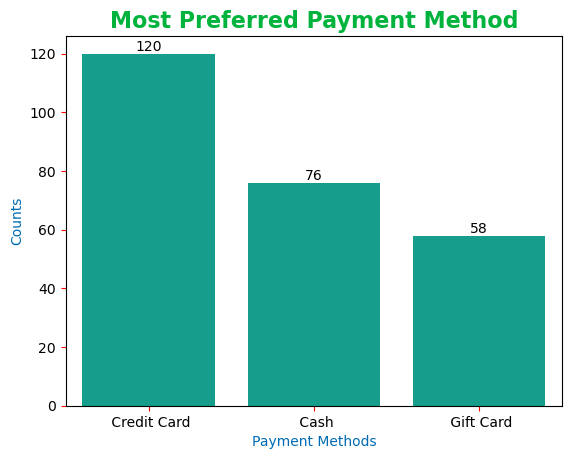

In [75]:
pt_md = df.payment_method.value_counts()
plt.title('Most Preferred Payment Method', color = '#00b33c',fontsize = 16, fontweight = 'bold')
plt.xlabel('Payment Methods',color = '#006bb3')
plt.ylabel('Counts',color = '#006bb3')
plt.tick_params(axis='both', color = 'red')
ax = sns.barplot(x = pt_md.index, y = pt_md.values,color='#00b39b')
for bar in ax.containers:
    ax.bar_label(bar)
plt.show()

From the above graph we can see that most preffered payment method is Credit Card.

#### Q.2) Most Selling Product ?
- By Quantity
- By Revenue


#### By Quantity

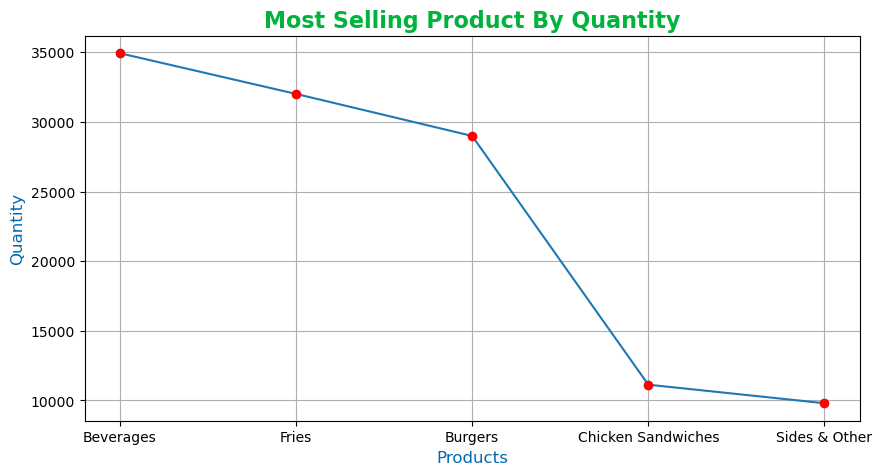

In [109]:
qty = df.groupby('product').quantity.sum().sort_values(ascending=False)
plt.figure(figsize = (10,5))
plt.title('Most Selling Product By Quantity',color = '#00b33c',fontsize = 16, fontweight = 'bold')
plt.xlabel('Products',color = '#006bb3',fontsize = 12,fontweight = 'medium')
plt.ylabel('Quantity',color = '#006bb3',fontsize = 12,fontweight = 'medium')
qty = plt.plot(qty.index,qty.values,marker = 'o', mfc = 'Red', mec = 'Red')
plt.grid()
plt.show()

In this graph the Mose selling product by quantity is beverage

#### By Revenue

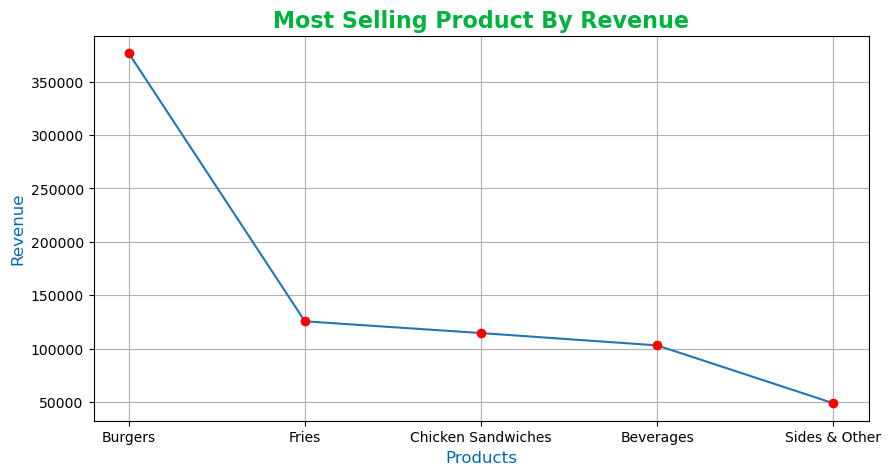

In [108]:
qty = df.groupby('product').revenue.sum().sort_values(ascending=False)
plt.figure(figsize = (10,5))
plt.title('Most Selling Product By Revenue',color = '#00b33c',fontsize = 16, fontweight = 'bold')
plt.xlabel('Products',color = '#006bb3',fontsize = 12,fontweight = 'medium')
plt.ylabel('Revenue',color = '#006bb3',fontsize = 12,fontweight = 'medium')
qty = plt.plot(qty.index,qty.values,marker = 'o', mfc = 'Red', mec = 'Red')
plt.grid()
plt.show()

In this graph the Mose selling product by revenue is burger

#### Q.3) Which city had maximum revenue
##### or
##### Which Manager earned maximum revenue

In [104]:
df.head(2)

,order_id,date,product,price,quantity,purchase_type,payment_method,manager,city,revenue
0,10452,2022-11-07,Fries,3.49,573,Online,Gift Card,Tom Jackson,London,1999.77
1,10453,2022-11-07,Beverages,2.95,745,Online,Gift Card,Pablo Perez,Madrid,2197.75


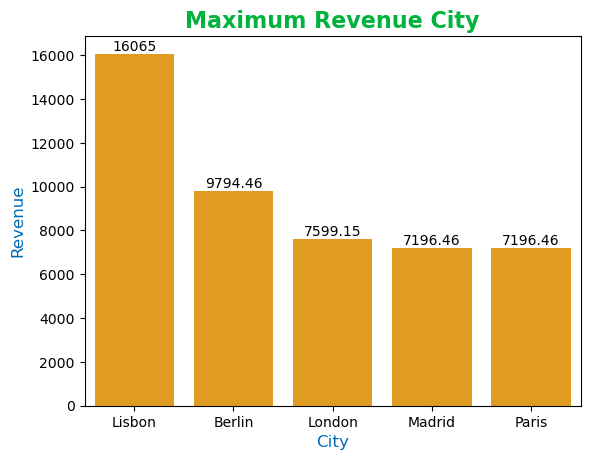

In [113]:
city = df.groupby('city').revenue.max().sort_values(ascending=False)
plt.title('Maximum Revenue City',color = '#00b33c',fontsize = 16, fontweight = 'bold')
plt.xlabel('City',color = '#006bb3',fontsize = 12,fontweight = 'medium')
plt.ylabel('Revenue',color = '#006bb3',fontsize = 12,fontweight = 'medium')
ax = sns.barplot(x = city.index, y = city.values, color='Orange')
for i in ax.containers:
    ax.bar_label(i)


From the above graph, the maximim revenue city is Lisbon

#### Q.4) Date wise revenue

In [114]:
df.head(2)

,order_id,date,product,price,quantity,purchase_type,payment_method,manager,city,revenue
0,10452,2022-11-07,Fries,3.49,573,Online,Gift Card,Tom Jackson,London,1999.77
1,10453,2022-11-07,Beverages,2.95,745,Online,Gift Card,Pablo Perez,Madrid,2197.75


In [115]:
df.groupby('date').revenue.sum()

date
2022-11-07     5195.52
2022-11-08    12389.03
2022-11-09    14191.33
2022-11-10    13193.33
2022-11-11    14390.26
2022-11-12    13987.57
2022-11-13    27659.02
2022-11-14    17826.67
2022-11-15    13593.79
2022-11-16    13593.79
2022-11-17    13987.57
2022-11-18    14381.35
2022-11-19    13991.65
2022-11-20     8196.18
2022-11-21    13984.41
2022-11-22    13581.72
2022-11-23    13789.56
2022-11-24    13590.63
2022-11-25    13382.79
2022-11-26    13187.94
2022-11-27    13382.79
2022-11-28    13390.03
2022-11-29    13390.03
2022-11-30    13584.88
2022-12-01    13385.95
2022-12-02    13987.57
2022-12-03    13987.57
2022-12-04     8988.57
2022-12-05    14191.33
2022-12-06    13983.49
2022-12-07    13987.57
2022-12-08    14182.42
2022-12-09    14585.11
2022-12-10    14585.11
2022-12-11    14993.55
2022-12-12    14585.11
2022-12-13    14585.11
2022-12-14    14589.26
2022-12-15    14381.42
2022-12-16    14984.71
2022-12-17    15391.48
2022-12-18    15586.33
2022-12-19    15790.09
2022-1

#### Q.5) Average Revenue

In [117]:
df.revenue.mean().round(2)

np.float64(3026.9)

#### Q.6) Average Revenue of November & December month

In [123]:
df[(df.date.dt.month == 11) | (df.date.dt.month == 12)].revenue.mean().round(2)

np.float64(3026.9)

#### Q.7) Standard Deviation of Revenue and Quantity ?

In [126]:
df.revenue.std()
df.quantity.std()

214.69197583196447

#### Q.8) Variance of Revenue and Quantity ?

In [128]:
df.revenue.var()
df.quantity.var()

46092.64448663282

#### Q.9) Is revenue increasing or decreasing over time?

In [137]:
df.groupby('date').revenue.sum().round(2)

date
2022-11-07     5195.52
2022-11-08    12389.03
2022-11-09    14191.33
2022-11-10    13193.33
2022-11-11    14390.26
2022-11-12    13987.57
2022-11-13    27659.02
2022-11-14    17826.67
2022-11-15    13593.79
2022-11-16    13593.79
2022-11-17    13987.57
2022-11-18    14381.35
2022-11-19    13991.65
2022-11-20     8196.18
2022-11-21    13984.41
2022-11-22    13581.72
2022-11-23    13789.56
2022-11-24    13590.63
2022-11-25    13382.79
2022-11-26    13187.94
2022-11-27    13382.79
2022-11-28    13390.03
2022-11-29    13390.03
2022-11-30    13584.88
2022-12-01    13385.95
2022-12-02    13987.57
2022-12-03    13987.57
2022-12-04     8988.57
2022-12-05    14191.33
2022-12-06    13983.49
2022-12-07    13987.57
2022-12-08    14182.42
2022-12-09    14585.11
2022-12-10    14585.11
2022-12-11    14993.55
2022-12-12    14585.11
2022-12-13    14585.11
2022-12-14    14589.26
2022-12-15    14381.42
2022-12-16    14984.71
2022-12-17    15391.48
2022-12-18    15586.33
2022-12-19    15790.09
2022-1

#### Q.10) Average 'Quantity Sold' & 'Average Revenue' for each product ?

In [139]:
df.quantity.mean()

np.float64(460.1653543307087)

In [140]:
df.revenue.mean()

np.float64(3026.8967716535435)